# Adsorption energy calculation

Adsorption energy measures how strongly a reaction intermediate binds to a catalyst surface, and it governs whether a catalyst is too reactive, too inert, or just right according to the Sabatier principle. For the oxygen reduction reaction (ORR), the relevant intermediates are O, OH, and OOH, and their adsorption energies on a given surface determines the theoretical overpotential and catalytic activity. This notebook gives the full workflow for calculating the OH adsorption energy on a Pt(111) surface using GFN1-xTB via TBLite. The ORR is introduced as a four-electron, proton-coupled process with an equilibrium potential of 1.23 V.

From there, the notebook builds and optimizes the molecular references needed (O₂, H₂O, H₂), constructs and optimizes a Pt(111) slab, places an OH adsorbate at the ontop site, and relaxes it with a substrate constraint. The second half covers thermochemical corrections: vibrational normal mode analysis with the ASE Vibrations module is demonstrated first on a free H₂O molecule (with animated GIF visualization of all modes) and then on the adsorbed OH, using IdealGasThermo for gas-phase species and HarmonicThermo for the adsorbate. The corrected adsorption free energy is then assembled from these components.

### Downloading packages

In [1]:
######################################################
##-install the necessery packages for this tutorial-##
######################################################

%%capture
!apt-get install imagemagick
!pip install ase tblite

### Importing libraries
ASE is a general packages to work with chemical structures in a sorted manner where every one can incorperate their own workflows and calculation methods into. As such it is surported by a wide range of other python packages and programs which then handles the actual Quantum chemical calculations.

In [2]:
#########################
##-Importing libraries-##
#########################

##-System
import os
import subprocess
import re
import io

##-Data
import numpy as np
import pandas as pd
import time

##-Visualization
import matplotlib.pyplot as plt
from IPython.display import Image ##.function for illustrating the system in 2d

##-ASE - structure building
from ase import Atoms
from ase.build import fcc111, add_adsorbate, molecule

##-ASE - I/O and visualization
from ase.io import read, write
from ase.visualize import view
from ase.io.trajectory import Trajectory
from IPython.display import HTML
from PIL import Image as PILImage
from ase.data.colors import jmol_colors
from ase.utils import rotate

##-ASE - simulation
from ase.optimize import GPMin, BFGS, FIRE
from ase.constraints import FixAtoms, FixedLine
from ase.thermochemistry import IdealGasThermo, HarmonicThermo
from ase.vibrations import Vibrations
from ase.data import covalent_radii
from ase.neighborlist import NeighborList, natural_cutoffs

##-Calculator
from tblite.ase import TBLite

In this tutorial we cover:
1. Introduction to oxygen reduction reaction;
2. Reaction mechanisms;
3. Calculating adsorption energies;
4. Corrections to calculated adsorption energies.


### Oxygen reduction reaction

The oxygen reduction reaction (ORR) is a fundamental electrochemical process, especially significant in fuel cells, where oxygen is reduced at the cathode.

The reaction proceeds as follows:

$\mathrm{O}_2 + 4\mathrm{H}^+ + 4e^- ⟶ 2\mathrm{H}_2\mathrm{O} \quad U_{\mathrm{eq}} = 1.23 \mathrm{V}$

Here, $U_{\mathrm{eq}} = 1.23 \mathrm{V}$ represents the equilibrium potential for ORR under standard conditions (298 K, 10⁵ Pa). The efficiency of ORR catalysts relies heavily on their ability to facilitate this multi-electron, proton-coupled transfer process.

Calculating adsorption energies for ORR intermediates like O, OH, and OOH on catalyst surfaces provides insight into the reaction's energetics and the catalyst's performance.

First, we start by creating the models of $\mathrm{O}_2 $, $\mathrm{H}_2\mathrm{O}$, and $\mathrm{H}_2$. These molecules are reactants and products in the ORR.

In [3]:
O2 = molecule("O2")
H2O = molecule("H2O")
H2 = molecule("H2")

We can visualise to confirm we have correctly created the structures:

In [4]:
view(H2O, viewer='x3d') ##-x3d is a backend illustrator program, which we need for working in notebooks

In [5]:
##-Visualize H2
view(H2, viewer='x3d')

In [6]:
##-Visualize O2
view(O2, viewer='x3d')

### Calculating energy of a molecule

In [7]:
calc = TBLite(
    method="GFN1-xTB",
    max_iterations=500,
    accuracy=1,
    verbosity=0
    )

In [8]:
H2O.calc = calc

dyn = BFGS(H2O, trajectory='H2O.traj')
dyn.run(fmax=0.01)

write('H2O.xyz', H2O)

E_H2O = H2O.get_potential_energy()
print(f"[+] The energy of H2O is {E_H2O:.2f} eV")

      Step     Time          Energy          fmax
BFGS:    0 07:08:54     -156.967506        0.784253
BFGS:    1 07:08:54     -156.974275        0.192546
BFGS:    2 07:08:54     -156.975042        0.127393
BFGS:    3 07:08:54     -156.976292        0.062845
BFGS:    4 07:08:54     -156.976357        0.018218
BFGS:    5 07:08:54     -156.976362        0.000753
[+] The energy of H2O is -156.98 eV


In [9]:
H2.calc = calc

dyn = BFGS(H2, trajectory='H2.traj')
dyn.run(fmax=0.01)

write('H2.xyz', H2)

E_H2 = H2.get_potential_energy()
print(f"[+] The energy of H2 is {E_H2:.2f} eV")

      Step     Time          Energy          fmax
BFGS:    0 07:08:54      -28.190285        1.447071
BFGS:    1 07:08:54      -28.206481        0.577123
BFGS:    2 07:08:54      -28.210235        0.052670
BFGS:    3 07:08:54      -28.210264        0.002317
[+] The energy of H2 is -28.21 eV


In [10]:
O2.calc = calc

dyn = BFGS(O2, trajectory='O2.traj')
dyn.run(fmax=0.01)

write('O2.xyz', O2)

E_O2 = O2.get_potential_energy()
print(f"[+] The energy of O2 is {E_O2:.2f} eV")

      Step     Time          Energy          fmax
BFGS:    0 07:08:54     -248.043075        3.106036
BFGS:    1 07:08:54     -247.979032        5.346838
BFGS:    2 07:08:54     -248.104037        0.542507
BFGS:    3 07:08:54     -248.105664        0.083985
BFGS:    4 07:08:54     -248.105703        0.001665
[+] The energy of O2 is -248.11 eV


### Create surface slabs

Slab models allow us to simulate surfaces of catalysts, which play the central role in electrocatalysis.

In [11]:
slab = fcc111('Pt', (3, 3, 5), a=3.9936, vacuum=10.0)
slab.pbc = [True, True, True]

In [12]:
##-optimize the slab
##-attach the calculator object to the Atoms object

slab.calc = calc
##-initialise a restrain object; fixing the bottom layer with according to the atoms with the lowest Z position
fixlayers = FixAtoms([atom.index for atom in slab if atom.position[2] == min(slab.positions[:, 2])])

##-attach the contraint object to the atom obj
slab.set_constraint([fixlayers])

##-run the obtimisation like with the molecules
dyn = BFGS(slab, trajectory='Pt111.traj')
dyn.run(fmax=0.1)

write('Pt111.xyz', slab)

      Step     Time          Energy          fmax
BFGS:    0 07:09:17    -5556.405009        0.780577
BFGS:    1 07:09:31    -5556.588369        0.750329
BFGS:    2 07:09:52    -5557.328951        0.913001
BFGS:    3 07:10:10    -5557.764744        0.354493
BFGS:    4 07:10:25    -5557.822213        0.316166
BFGS:    5 07:10:38    -5557.846280        0.294653
BFGS:    6 07:10:53    -5557.912752        0.272587
BFGS:    7 07:11:08    -5558.043981        0.325129
BFGS:    8 07:11:25    -5558.213796        0.327477
BFGS:    9 07:11:41    -5558.323017        0.246280
BFGS:   10 07:11:55    -5558.371851        0.146095
BFGS:   11 07:12:06    -5558.379573        0.125017
BFGS:   12 07:12:17    -5558.390673        0.181791
BFGS:   13 07:12:26    -5558.416764        0.257359
BFGS:   14 07:12:42    -5558.466624        0.322335
BFGS:   15 07:12:57    -5558.543454        0.329710
BFGS:   16 07:13:13    -5558.619062        0.242442
BFGS:   17 07:13:25    -5558.650064        0.173899
BFGS:   18 07:

/usr/local/lib/python3.12/dist-packages/ase/io/extxyz.py:320: UserWarning: Skipping unhashable information adsorbate_info
  warnings.warn('Skipping unhashable information '


In [13]:
##-Visualize the final optimization structure to verify it optimized properly
view(slab*(4,4,1), viewer='x3d') ##-For visualisation we repeat the slab four times in XY direction to show a surface

## Add adsorbates to the model surface

Let us add molecular adsorbates (O, OH, OOH) onto the catalyst surface. This setup simulates adsorption mechanism, enabling us to calculate the adsorption energies and then the energy changes between steps within the reaction mechanism.

In [14]:
specie = Atoms('OH', positions=[(0, 0, 0), (0.7, 0, 0.7)]) ##-Define our adsorbate as a new atom object in its own coordinate basis.

slab_oh = slab.copy()

add_adsorbate(
    slab=slab_oh,
    adsorbate=specie,
    height=1.9, ##-distance between the binding site in the slab to the origo in the adsorbate coordinate system
    position="ontop" ##-note this function only work because of the tags placed on the slab Atoms object by the official ASE builder
)

Let us view the result before the optimization:

In [15]:
view(slab_oh, viewer='x3d')

In [16]:
##-optimise the slab with adsorbate

constraint = FixAtoms(mask=[atom.tag > 1 for atom in slab_oh])

slab_oh.set_constraint(constraint)

slab_oh.calc = TBLite(
    method='GFN1-xTB',
    electronic_temperature=10, ##-Helps with convergence, smoothing the electron density
    max_iterations=1000,
    verbosity=1
    )

dyn = BFGS(slab_oh, trajectory='Pt111_OH.traj')
dyn.run(fmax=0.1) ##-adsorbate is more difficult to converge

write('Pt111_OH.xyz', slab)

------------------------------------------------------------
  cycle        total energy    energy error   density error
------------------------------------------------------------
      1     -168.2333889838  -1.6770567E+02   1.1087574E+00
      2      438.1829553957   6.0641634E+02   2.1600472E+00
      3      1283.700200168   8.4551724E+02   2.4722749E+00
      4      439.5425465671  -8.4415765E+02   1.7174860E+00
      5      683.7248482444   2.4418230E+02   1.8564509E+00
      6     -117.3901274619  -8.0111498E+02   1.1737494E+00
      7      295.3888545846   4.1277898E+02   1.7566202E+00
      8     -27.92262806848  -3.2331148E+02   1.5147582E+00
      9     -122.9976099601  -9.5074982E+01   1.0491421E+00
     10     -163.5141351522  -4.0516525E+01   8.7414440E-01
     11     -163.6753498800  -1.6121473E-01   8.8955100E-01
     12     -123.1814724770   4.0493877E+01   1.0311154E+00
     13     -110.9442598517   1.2237213E+01   1.0690421E+00
     14     -98.06119691832   1.288306

In [17]:
view(slab_oh*(4,4,1), viewer='x3d')

In [18]:
##-Visualize a smaller cell to check OH adsorbate
view(slab_oh, viewer='x3d')

#### Corrections to Adsorption Energies

The very first correction to the adsorption energy accounts for the zero-point energy.

$$
E_{\text{ad}} = E_{\text{calc}} + \Delta E_{\text{ZPE}}
$$

where:
- $E_{\text{calc}}$ is the initially calculated adsorption energy.
- $\Delta E_{\text{ZPE}}$ is the zero-point energy correction.

This correction provides a more realistic representation of adsorption energies under experimental conditions than pure DFT groundstate energies.

To calcualte ZPE we must simulate vibrations of molecules using ASE thermochemistry module.
Here for visual illustration purposes we start with a water molecules before we move on to the slab.

In [19]:
##-Create and optimise water molecule
atoms = molecule('H2O')

atoms.calc = TBLite(method='GFN1-xTB')

atoms.center()

dyn = BFGS(atoms, trajectory='H2O.traj')
dyn.run(fmax=0.01)

write('H2O.xyz', atoms)

##-Set up vibration calculations using the previously optimized molecule
vib = Vibrations(atoms)
vib.run()

##-Write the vibration trajectories to trajectory files
for mode in range( 3*len(atoms.numbers) ):
  vib.write_mode(mode)

##-Show the output of vibration analysis
print("[+] Vibration analysis summary:")
vib.summary() # will write the output in stdout

------------------------------------------------------------
  cycle        total energy    energy error   density error
------------------------------------------------------------
      1     -5.716569333003  -5.7508534E+00   6.2169684E-01
      2     -5.761623337778  -4.5054005E-02   2.7410550E-01
      3     -5.768251583325  -6.6282455E-03   5.2108491E-02
      4     -5.768402894090  -1.5131076E-04   1.3511931E-02
      5     -5.768449466171  -4.6572081E-05   3.1448761E-04
      6     -5.768449492510  -2.6338962E-08   1.3161127E-05
------------------------------------------------------------

 total:                                   0.016 sec
      Step     Time          Energy          fmax
BFGS:    0 07:29:00     -156.967506        0.784253
------------------------------------------------------------
  cycle        total energy    energy error   density error
------------------------------------------------------------
      1     -5.768695254689  -5.8072427E+00   6.8380914E-03


In [20]:
##-Calculate entropy correction of the H2O molecule
##-Perform the calculations, assuming ideal gas model (no interactions between species)
vib_energies = vib.get_energies()
potentialenergy = atoms.get_potential_energy()

thermo = IdealGasThermo(
    vib_energies = vib_energies,
    potentialenergy = potentialenergy,
    atoms=atoms,
    geometry='nonlinear', ##-adjust acording to the atomic system
    symmetrynumber=2, ##-adjust this if needed
    spin=0 ##-adjust this if needed
    )
##-Calculate respective corrections at temperature and pressure specified
G_h2o = thermo.get_gibbs_energy(temperature=298.15, pressure=101325) ##-standard asmopheric temperature and presure

------------------------------------------------------------
  cycle        total energy    energy error   density error
------------------------------------------------------------
      1     -5.768774701733  -5.8064775E+00   1.8459256E-03
      2     -5.768774907127  -2.0539477E-07   9.6014713E-04
      3     -5.768774930690  -2.3562385E-08   1.9959340E-04
      4     -5.768774932920  -2.2298741E-09   8.0053780E-06
------------------------------------------------------------

 total:                                   0.010 sec
Enthalpy components at T = 298.15 K:
Enthalpy components at T = 298.15 K:
E_pot               -156.976 eV
E_ZPE                  0.552 eV
Cv_trans (0->T)        0.039 eV
Cv_rot (0->T)          0.039 eV
Cv_vib (0->T)          0.000 eV
-------------------------------
U                   -156.347 eV
(C_v -> C_p)           0.026 eV
-------------------------------
H                   -156.322 eV

Entropy components at T = 298.15 K and P = 101325.0 Pa:
{"":15s}{"S":

In [21]:
##-Use the optimized H2 structure
H2_thermo = read("H2.xyz")

H2_thermo.calc = TBLite(
    method="GFN1-xTB",
    max_iterations=500,
    accuracy=1,
    verbosity=0
)

vib_h2 = Vibrations(H2_thermo, name="vib_H2")
vib_h2.run()

vib_h2.summary()

##-Get vibrational energies
vib_energies_H2 = vib_h2.get_energies()

##-Ideal gas thermochemistry for H2
thermo_H2 = IdealGasThermo(
    vib_energies=vib_energies_H2,
    potentialenergy=E_H2,
    atoms=H2_thermo,
    geometry="linear",
    symmetrynumber=2,
    spin=0
)

G_h2 = thermo_H2.get_gibbs_energy(temperature=298.15,pressure=101325)

---------------------
  #    meV     cm^-1
---------------------
  0    0.0       0.0
  1    0.0       0.0
  2    0.0       0.0
  3    2.8      22.6
  4    2.8      22.6
  5  621.8    5015.4
---------------------
Zero-point energy: 0.314 eV
Enthalpy components at T = 298.15 K:
Enthalpy components at T = 298.15 K:
E_pot                -28.210 eV
E_ZPE                  0.311 eV
Cv_trans (0->T)        0.039 eV
Cv_rot (0->T)          0.026 eV
Cv_vib (0->T)          0.000 eV
-------------------------------
U                    -27.835 eV
(C_v -> C_p)           0.026 eV
-------------------------------
H                    -27.809 eV

Entropy components at T = 298.15 K and P = 101325.0 Pa:
{"":15s}{"S":13s}     {"T*S:13s}
S_trans (1 bar)    0.0012188 eV/K        0.363 eV
S_rot              0.0001376 eV/K        0.041 eV
S_elec             0.0000000 eV/K        0.000 eV
S_vib              0.0000000 eV/K        0.000 eV
S (1 bar -> P)    -0.0000011 eV/K       -0.000 eV
-------------------------

Let us visualize the vibrations. Below each mode is rendered as an animated GIF **with bonds drawn**, which makes it much easier to recognise the standard vibration types (symmetric/asymmetric stretching, scissoring, rocking, wagging, twisting).

For reference, the classic animation of the H$_2$O vibration types:
https://www.acamedia.info/sciences/J_G/envrad/microwaves/v1.gif

In [22]:
##-show the reference GIF on a white background (it is transparent, so it is
##-hard to see on the notebook's dark theme otherwise)
HTML('<div style="background:white;display:inline-block;padding:8px">'
     '<img src="https://www.acamedia.info/sciences/J_G/envrad/microwaves/v1.gif"></div>')

In [24]:
##-Helper: render a vibration trajectory as an animated GIF with bonds,
##-on a white background. Pure Python (ase + matplotlib + PIL) - no ImageMagick
##-or ffmpeg needed, so it runs anywhere the notebook runs.

def vib_gif(traj_frames, out_gif, rotation='-90z', bond_scale=1.1, atom_scale=0.45, figsize=3.0, duration=50):

  """Animated GIF of a vibration with bonds drawn, white background.

  traj_frames: list of Atoms, e.g. read('vib.5.traj', ':')
  rotation:    ASE rotation string or 3x3 matrix (same as write())
  """

  R = rotate(rotation) if isinstance(rotation, str) else np.asarray(rotation)

  # fixed axis limits over ALL frames so the animation does not jitter
  allpos = np.vstack([a.positions @ R for a in traj_frames])
  rmax = atom_scale * max(covalent_radii[a.numbers].max() for a in traj_frames)
  xlo, ylo = allpos[:, :2].min(axis=0) - 2 * rmax
  xhi, yhi = allpos[:, :2].max(axis=0) + 2 * rmax

  frames = []
  for atoms in traj_frames:
    pos = atoms.positions @ R

    nl = NeighborList(
        natural_cutoffs(atoms, mult=bond_scale),
        self_interaction=False,
        bothways=False
        )

    nl.update(atoms)

    fig, ax = plt.subplots(
        figsize=(figsize, figsize * (yhi - ylo) / (xhi - xlo))
        )

    for i in range(len(atoms)):
      nbrs, offsets = nl.get_neighbors(i)

      for j, off in zip(nbrs, offsets):
        if not off.any():  # skip bonds through periodic boundaries
          ax.plot(
              [pos[i, 0], pos[j, 0]],
              [pos[i, 1], pos[j, 1]],
              color='0.45',
              lw=2.0,
              zorder=1,
              solid_capstyle='round'
          )

    for i in np.argsort(pos[:, 2]):  # draw far atoms first
      ax.add_patch(plt.Circle(
          pos[i, :2],
          atom_scale * covalent_radii[atoms.numbers[i]],
          facecolor=jmol_colors[atoms.numbers[i]],
          edgecolor='black',
          lw=0.8,
          zorder=2
          )
      )

    ax.set_xlim(xlo, xhi); ax.set_ylim(ylo, yhi)
    ax.set_aspect('equal'); ax.axis('off')
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=110, facecolor='white', bbox_inches='tight', pad_inches=0.05)
    plt.close(fig)
    buf.seek(0)
    frames.append(PILImage.open(buf).convert('P', palette=PILImage.ADAPTIVE))

  frames[0].save(out_gif, save_all=True, append_images=frames[1:], duration=duration, loop=0)
  return out_gif

In [25]:
traj_h2o = [f'vib.{i}.traj' for i in [0, 4, 5, 6, 7, 8]]

for i, traj_file in enumerate(traj_h2o): ##-i is the number of vibration in sequence
  traj = read(traj_file, ':') ##-':' means read all structures in the trajectory
  vib_gif(traj, f'vib{i}.gif', rotation='75y,20x') ##-bonds + white background, written directly by PIL

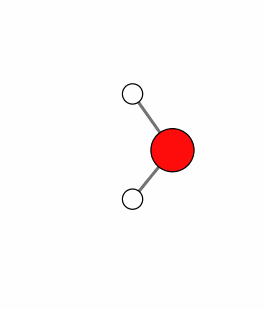

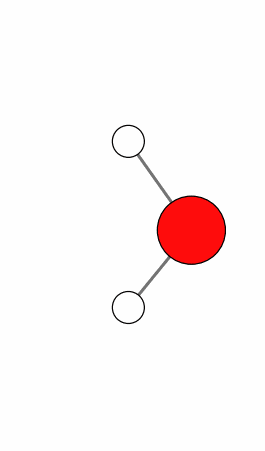

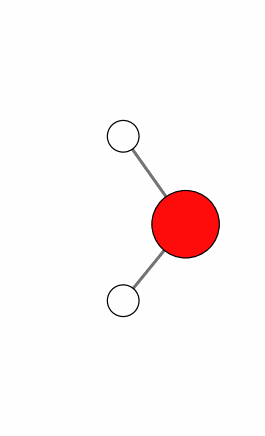

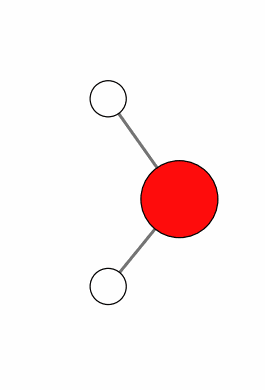

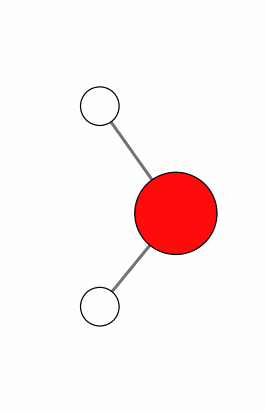

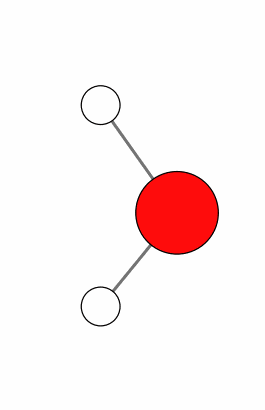

In [26]:
for i in range(6):
  display(Image(filename=f'vib{i}.gif'))

In a similar way, we can simulate the vibrations for adsorbate.

In [27]:
!rm -r vib*

##-Take the previously optimized slab
vib = Vibrations(
    slab_oh,
    indices = list(range(-2, 0)) ##-indicies states atoms we wish  to vibrate in this case the last two added which is our adsorbate
    )

print(slab_oh.calc)
vib.run()
vib.summary()

##-Save vibration modes to review if an imaginary frequency is present
for mode in range(2*3):
  vib.write_mode(mode)

------------------------------------------------------------
  cycle        total energy    energy error   density error
------------------------------------------------------------
      1     -209.5846835528  -2.0907493E+02   1.1738392E-03
      2     -209.1595804247   4.2510313E-01   5.1880690E-02
      3     -209.5728774584  -4.1329703E-01   9.3847107E-03
      4     -209.5840853264  -1.1207868E-02   6.5521623E-03
      5     -209.5818406343   2.2446921E-03   4.8417849E-03
      6     -209.5832725080  -1.4318737E-03   3.7579890E-03
      7     -209.5847755080  -1.5030000E-03   1.2362986E-03
      8     -209.5844763849   2.9912305E-04   1.9782387E-03
      9     -209.5847948801  -3.1849515E-04   2.7127347E-04
     10     -209.5847862788   8.6012992E-06   3.3131757E-04
     11     -209.5847982788  -1.1999978E-05   3.7623181E-04
     12     -209.5847946701   3.6087025E-06   4.0617369E-04
     13     -209.5848004079  -5.7378063E-06   1.8339636E-04
     14     -209.5848025259  -2.118078

In [28]:
atoms = Trajectory('vib.0.traj')[5]
atoms.calc = TBLite(method='GFN1-xTB')

dyn = BFGS(atoms, trajectory='opt.traj')
dyn.run(fmax=0.1)

energy_new = atoms.get_potential_energy()

!rm -r vib*

vib = Vibrations(atoms, indices=range(-2, 0))
vib.run()

vib.summary()

for mode in range(2*3):
  vib.write_mode(mode)

------------------------------------------------------------
  cycle        total energy    energy error   density error
------------------------------------------------------------
      1     -184.8783563102  -1.8436714E+02   1.0201481E+00
      2      1566.111936539   1.7509903E+03   2.5926342E+00
      3      1180.256802277  -3.8585513E+02   2.3391029E+00
      4     -124.4367778438  -1.3046936E+03   1.1116860E+00
      5      225.3492695362   3.4978605E+02   1.3944047E+00
      6      226.2057491398   8.5647960E-01   1.5048544E+00
      7      587.9681879810   3.6176244E+02   1.7765888E+00
      8      143.8020067435  -4.4416618E+02   1.3345806E+00
      9      257.9111243747   1.1410912E+02   1.4257984E+00
     10      26.89035899729  -2.3102077E+02   1.0408795E+00
     11     -67.86225654188  -9.4752616E+01   9.3202243E-01
     12     -112.3182181935  -4.4455962E+01   9.7041699E-01
     13     -129.3422305026  -1.7024012E+01   9.0881535E-01
     14     -140.0996846206  -1.075745

In [29]:
##-Calculate the entropy correction
##-Perform the calculations assuming ideal gas
vib_energies = vib.get_energies()
potentialenergy = atoms.get_potential_energy()

thermo = HarmonicThermo(
    vib_energies = vib_energies,
    potentialenergy = potentialenergy
    )

##-Calculate respective corrections at temperature and pressure specified
G_oh = thermo.get_internal_energy(temperature=298.15)
H_slab_oh = thermo.get_helmholtz_energy(temperature=298.15)
##-G = thermo.get_entropy(temperature=298.15)

------------------------------------------------------------
  cycle        total energy    energy error   density error
------------------------------------------------------------
      1     -209.5865558803  -2.0907819E+02   1.6084059E-03
      2     -207.3996398347   2.1869160E+00   1.0912016E-01
      3     -209.5748417707  -2.1752019E+00   7.1477684E-03
      4     -209.4667535576   1.0808821E-01   2.2137291E-02
      5     -209.5761697113  -1.0941615E-01   8.3694610E-03
      6     -209.5827950650  -6.6253537E-03   4.6965056E-03
      7     -209.5866352559  -3.8401909E-03   1.6752261E-03
      8     -209.5869308521  -2.9559624E-04   9.9192852E-04
      9     -209.5870742582  -1.4340606E-04   3.7122458E-04
     10     -209.5869970725   7.7185669E-05   5.9076493E-04
     11     -209.5870078296  -1.0757076E-05   5.4669119E-04
     12     -209.5870314106  -2.3581002E-05   4.5288378E-04
     13     -209.5870589456  -2.7535010E-05   3.0739506E-04
     14     -209.5870723916  -1.344603

It is common to use empirical values instead of calculating ZPE and TS values directly for every catalyst.

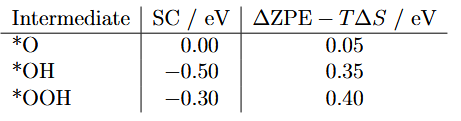

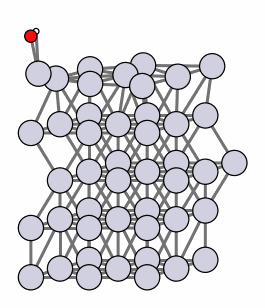

In [30]:
##-Visualise one of these vibrations as a .gif (bonds drawn, white background)
traj = Trajectory('vib.5.traj')
vib_gif(list(traj), 'vibration.gif', rotation='-80x')
Image(filename='vibration.gif')

## Calculation of adsorption energy
The reaction which we are finding the adsorption:
$$
H_{\text{2}}O + * ⟶ OH* + 0.5H_{\text{2}}
$$
The standard  way to calculate the dG is the following:
$$
\Delta G_A = \Delta E_A - T \Delta S + \int_{0}^{T} C_p \, dT + \Delta ZPE
$$
Currently we have energy for the bare slab and the slab with OH adsorbate. To get the rest of the terms we can use Helmholtz energy, which we calculated a few cells ago.
$$
H_{\mathrm{slab+OH}} = E_{\mathrm{slab+OH}} + ZPE + \int_{0}^{T} C_p \, dT - TS
$$
And since we have the energy for the slab with the OH we can simply subtract the energy of the slab with the OH adsorbate from the Gibbs energy of the slab with the adsorbate and get the rest of the terms:
$$
E_{\mathrm{OH^*,corr}} =
ZPE
+ \int_{0}^{T} C_p \, dT
- TS
$$
Combining everything together we get the final equation for calculating the adsorption energy:
$$
G_{\text{ad}} = G_{\text{slab+OH}} - G_{\text{slab}} - G_{\text{H2O}} + 0.5*G_{\text{H2}}
$$
Where:
$$
G_{\text{slab+OH}} - G_{\text{slab}} ≈ E_{\text{slab+OH}} -  E_{\text{slab}}
$$

In [31]:
######################################
##-Calculation of adsorption energy-##
######################################

E_slab = slab.get_potential_energy()
E_slab_oh = slab_oh.get_potential_energy()
E_oh_corr = H_slab_oh - E_slab_oh
dG_ads_OH = E_slab_oh - E_slab + E_oh_corr - G_h2o + 0.5*G_h2

print("ΔG_ads(OH*) =", round(dG_ads_OH, 3), "eV")

------------------------------------------------------------
  cycle        total energy    energy error   density error
------------------------------------------------------------
      1     -209.5847050052  -2.0907573E+02   1.4030600E-03
      2     -209.2424442557   3.4226075E-01   4.4023743E-02
      3     -209.5697114774  -3.2726722E-01   1.0820708E-02
      4     -209.5844110528  -1.4699575E-02   4.5169980E-03
      5     -209.5847466163  -3.3556347E-04   1.8969419E-03
      6     -209.5846567598   8.9856544E-05   1.7140042E-03
      7     -209.5841608461   4.9591369E-04   2.8599474E-03
      8     -209.5847368675  -5.7602141E-04   1.0753850E-03
      9     -209.5848036292  -6.6761743E-05   3.1351563E-04
     10     -209.5847885064   1.5122780E-05   4.7744484E-04
     11     -209.5848093958  -2.0889374E-05   1.1887196E-04
     12     -209.5848041108   5.2849968E-06   2.8604902E-04
     13     -209.5848106564  -6.5456230E-06   7.0272365E-05
     14     -209.5848108670  -2.105477

## Summary

After completing this notebook, you should be able to:
1. Build O₂, H₂O, and H₂ with ASE's molecule() function, attach a TBLite GFN1-xTB calculator, optimize each with BFGS, and extract the total energy for use as a thermochemical reference.
2. Generate a Pt(111) slab with fcc111(), freeze the bottom layer with FixAtoms to represent a rigid bulk, optimize the surface geometry, and verify the structure visually.
3. efine an OH fragment as an Atoms object, add it to the slab surface with add_adsorbate() at the ontop site, constrain all but the top layer with a tag-based mask, and run BFGS with an elevated electronic_temperature to help convergence.
4. Run vibrational analysis. Use ASE's Vibrations module to compute normal modes for free molecules and for adsorbed species (restricting the displacement to adsorbate atoms with the indices argument), read the vibrational summary, and write mode trajectories. Recognize that the first three (or five, for linear molecules) modes are translational and rotational, not vibrational.
5. Visualize normal modes as animated GIFs. Use the custom vib_gif() function, which renders each trajectory frame with matplotlib and Pillow without requiring ImageMagick or ffmpeg, producing a bond-drawn, white-background animation directly from Python.
6. Use IdealGasThermo for gas-phase molecules (specifying geometry, symmetry number, and spin) and HarmonicThermo for the surface adsorbate. Extract ZPE, heat capacity, and entropy contributions, then compute Gibbs free energies at 298.15 K and 1 atm.
7. Assemble the adsorption free energy. Combine the slab, slab-with-adsorbate, and molecular reference energies according to the reaction H₂O + * → OH* + 0.5 H₂, apply the Helmholtz correction for the adsorbate, and compute the final ΔG_ads.